=== PHASE 6: PUBLICATION-READY VISUALIZATIONS AND FINAL ANALYSES ===

=== PUBLICATION VIZ 1: COMPREHENSIVE HEATMAPS ===


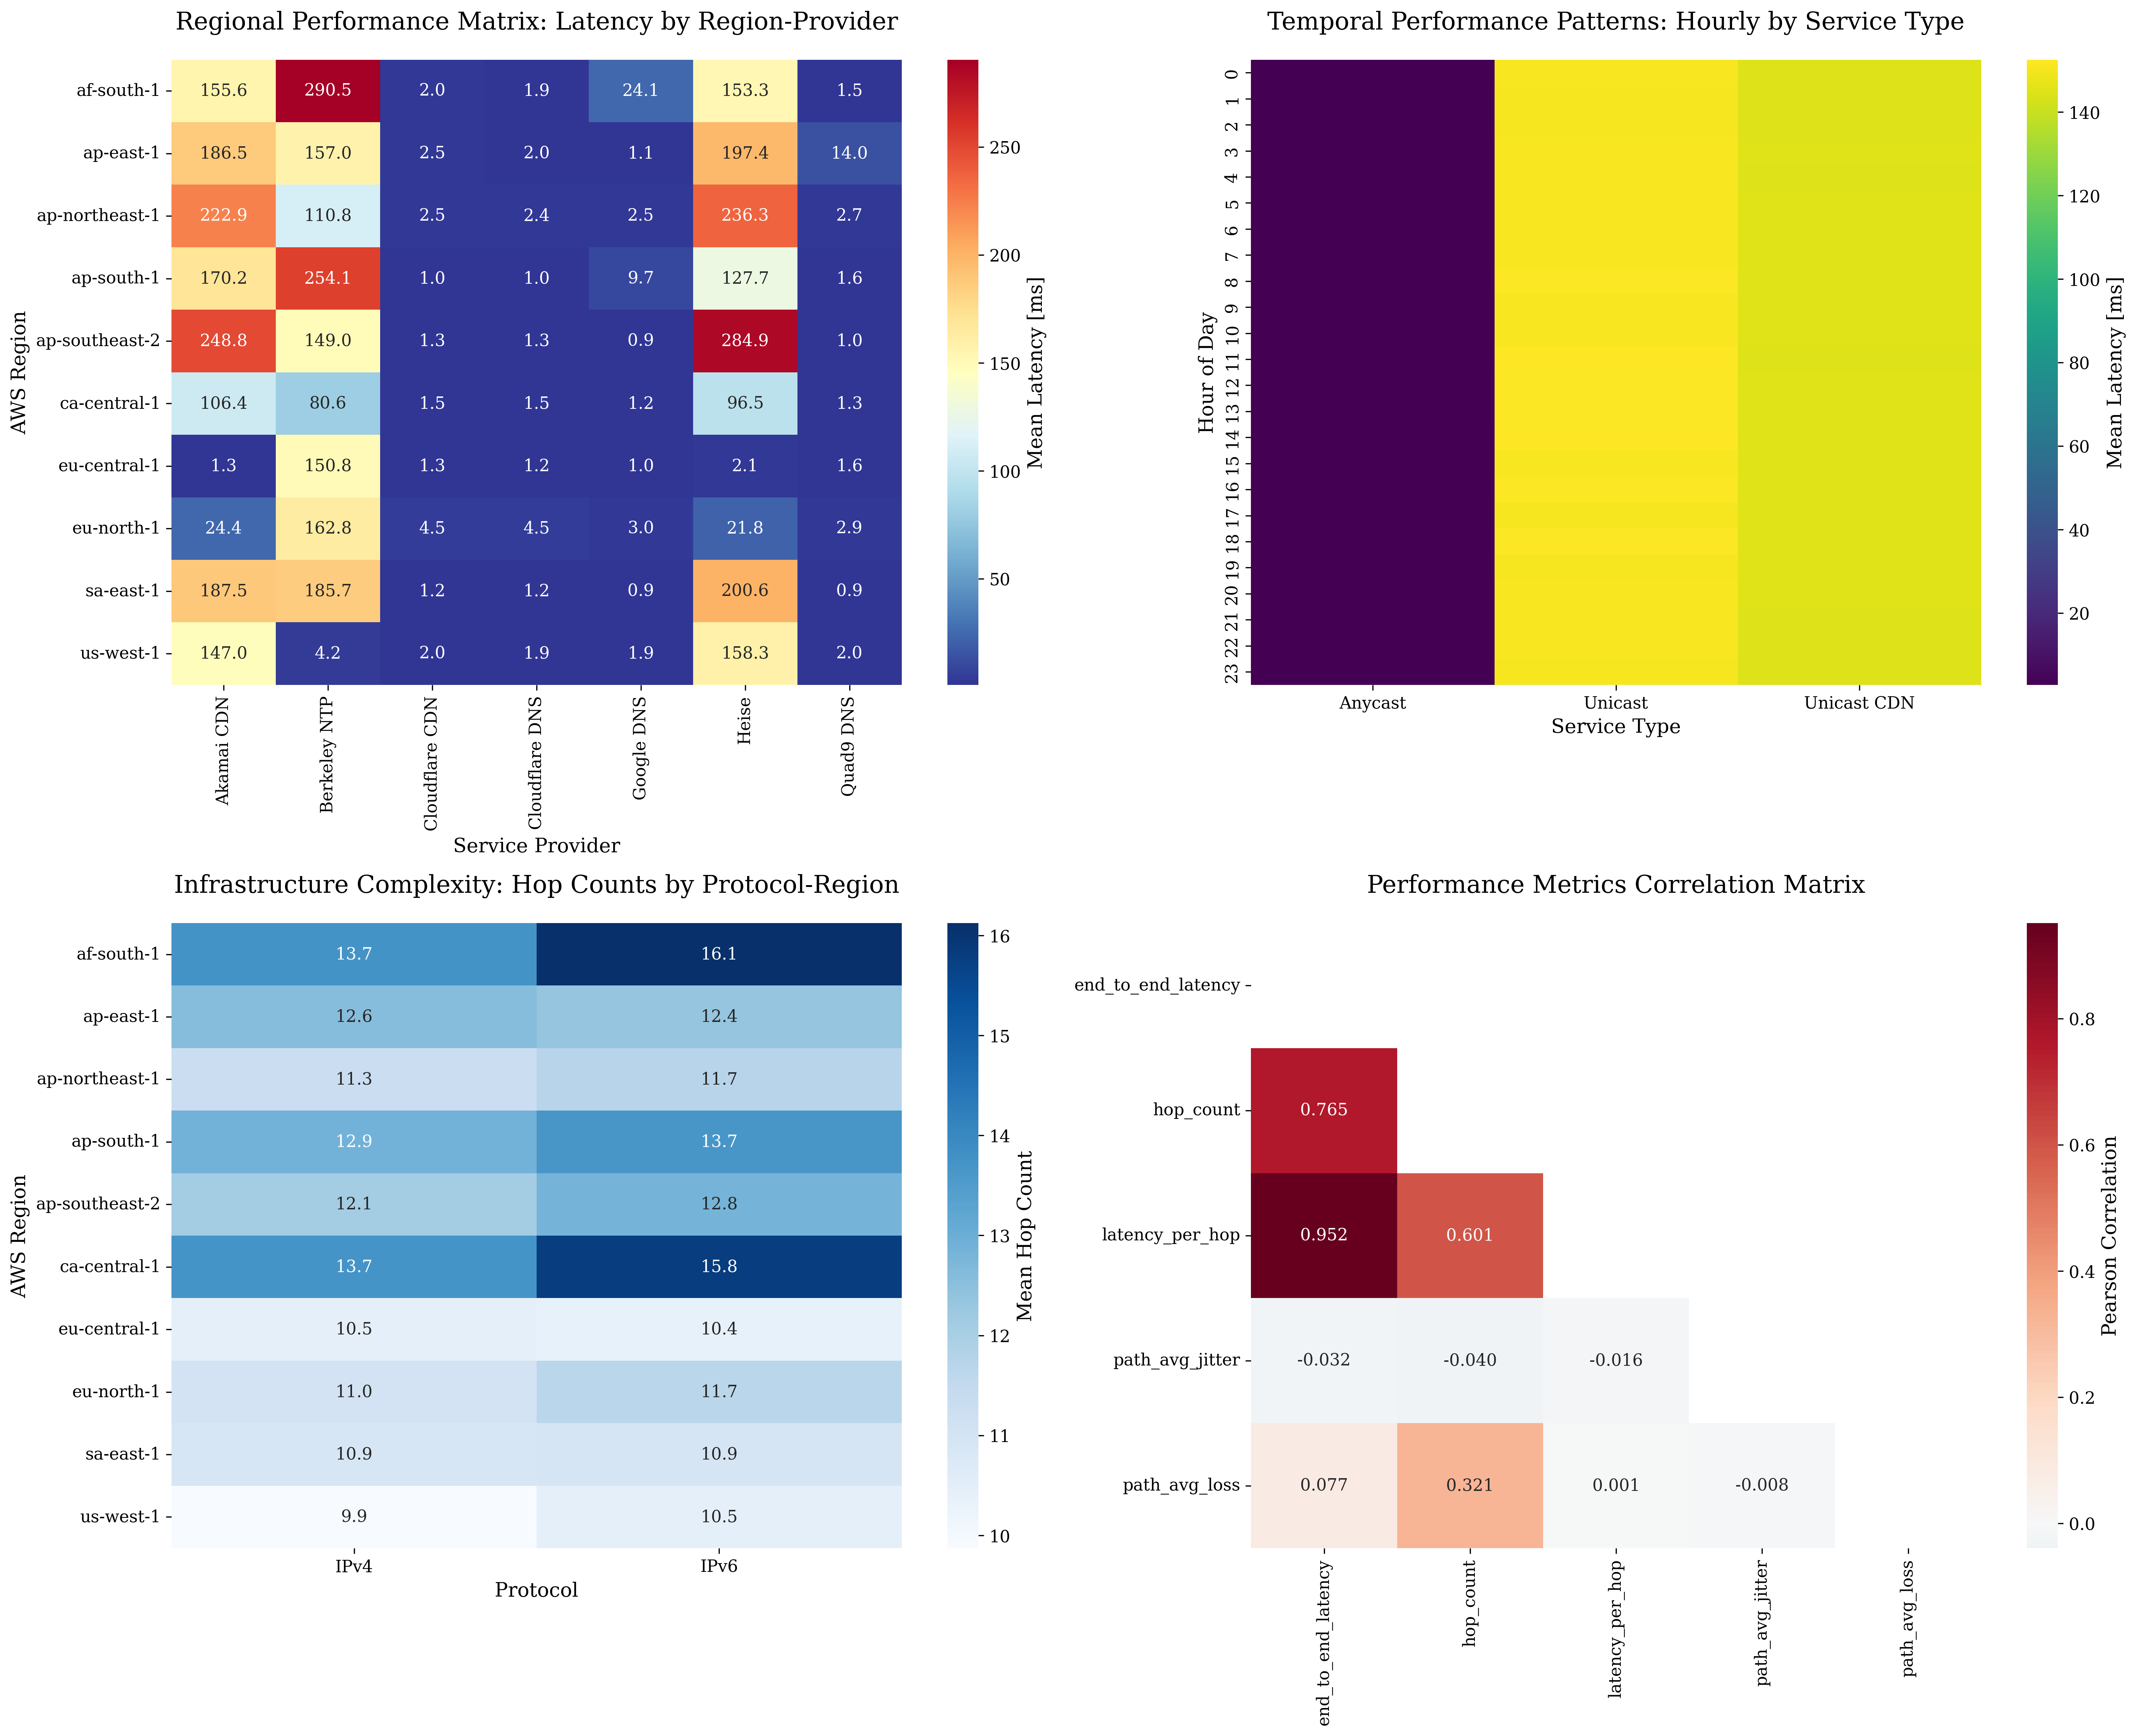


=== PUBLICATION VIZ 2: ADVANCED VIOLIN PLOTS ===


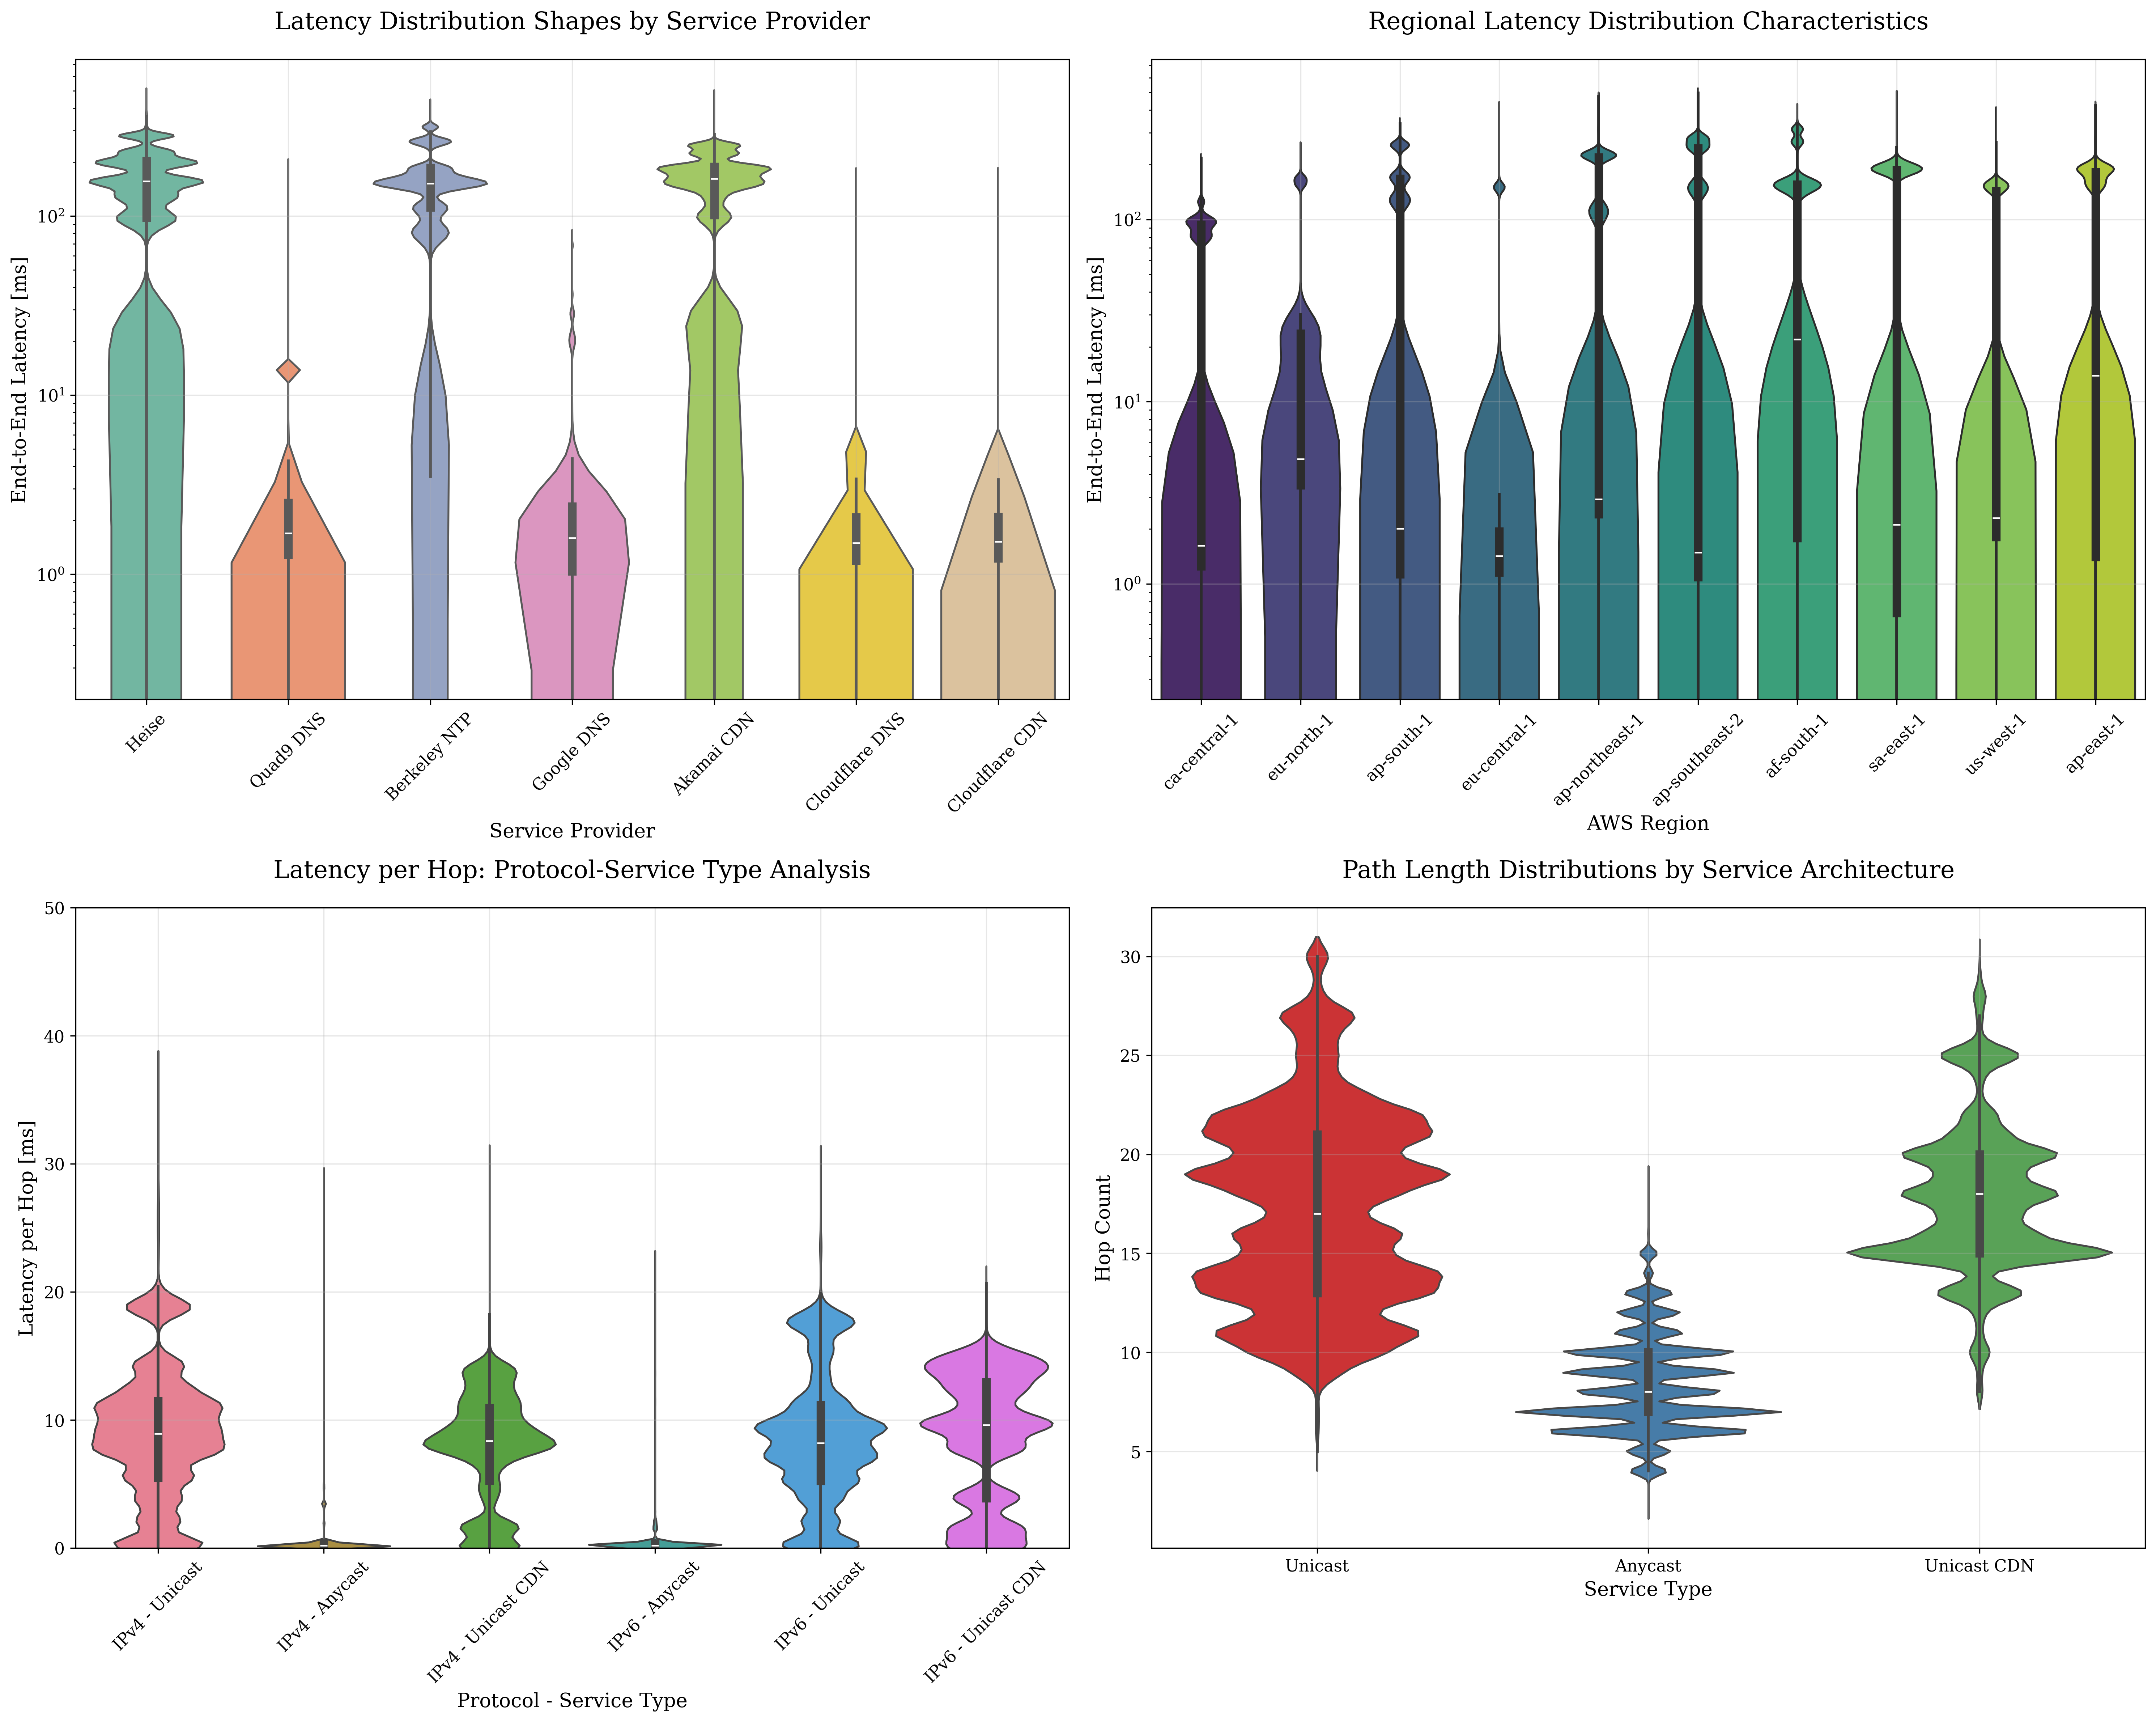


=== PUBLICATION VIZ 3: NETWORK TOPOLOGY ANALYSIS ===


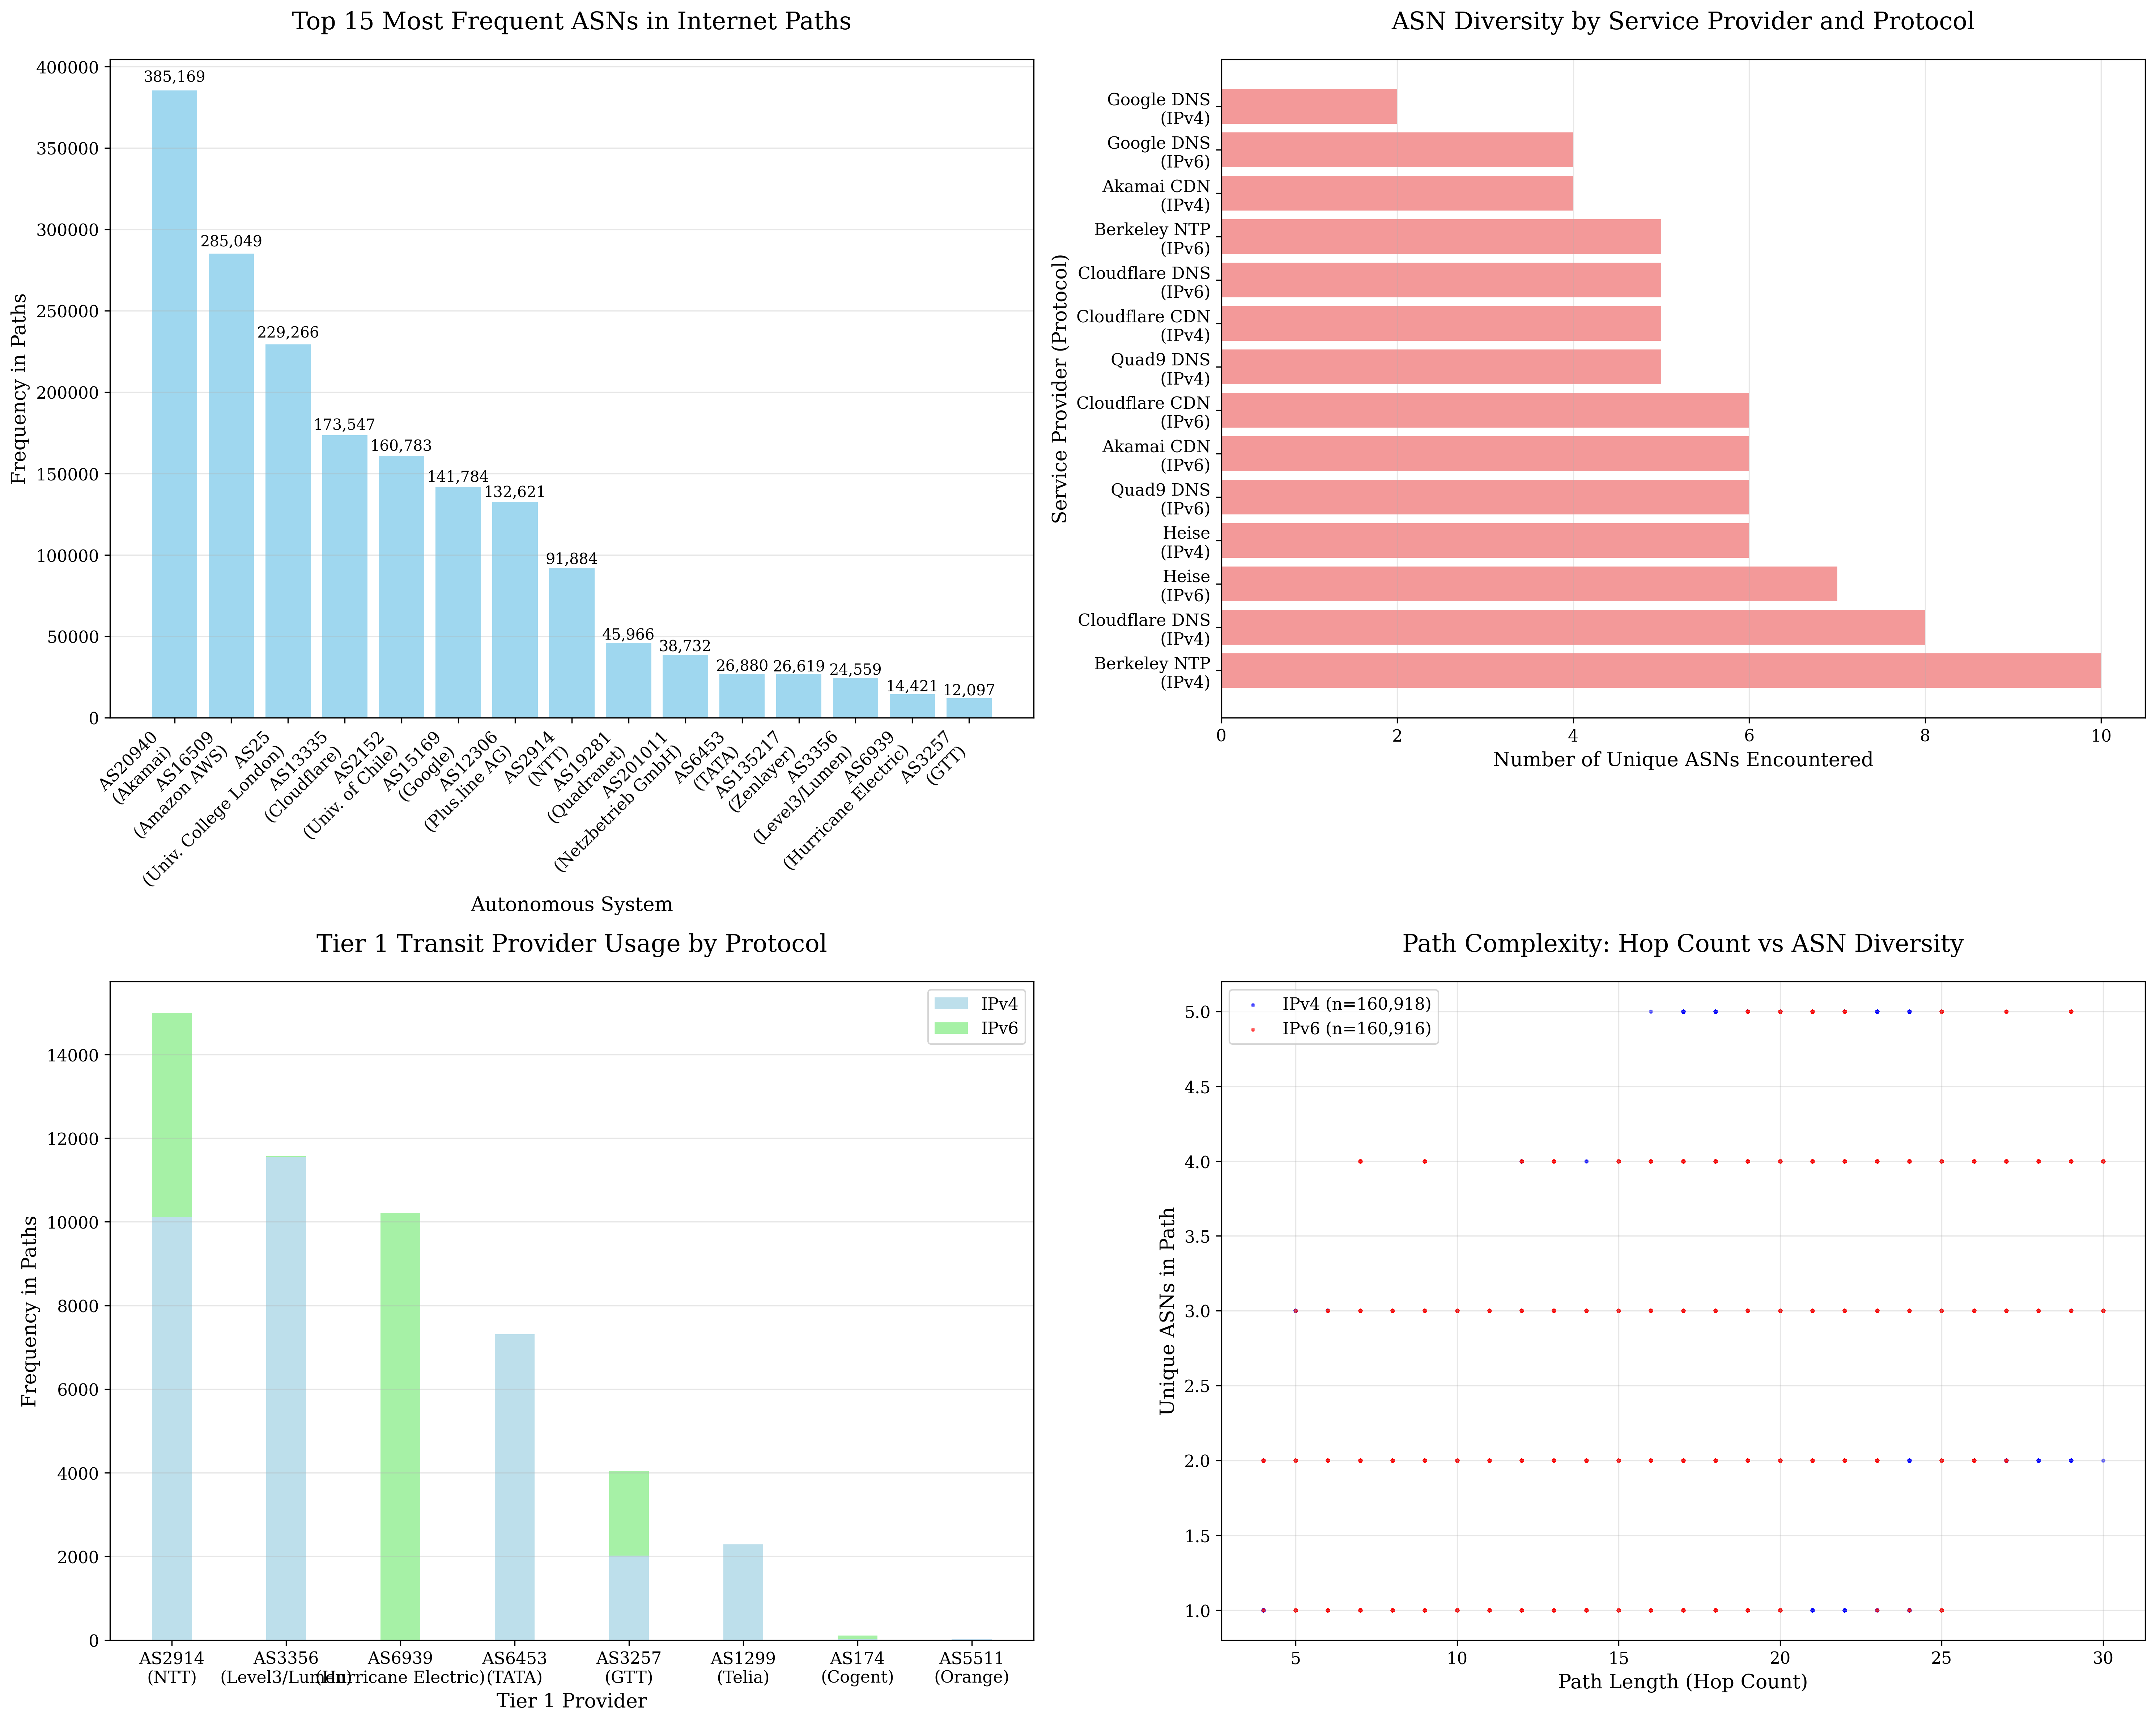

Network topology analysis completed
Total unique ASNs encountered: 27
Average path ASN diversity: 0.172

=== PUBLICATION VIZ 4: STATISTICAL SIGNIFICANCE TESTING ===


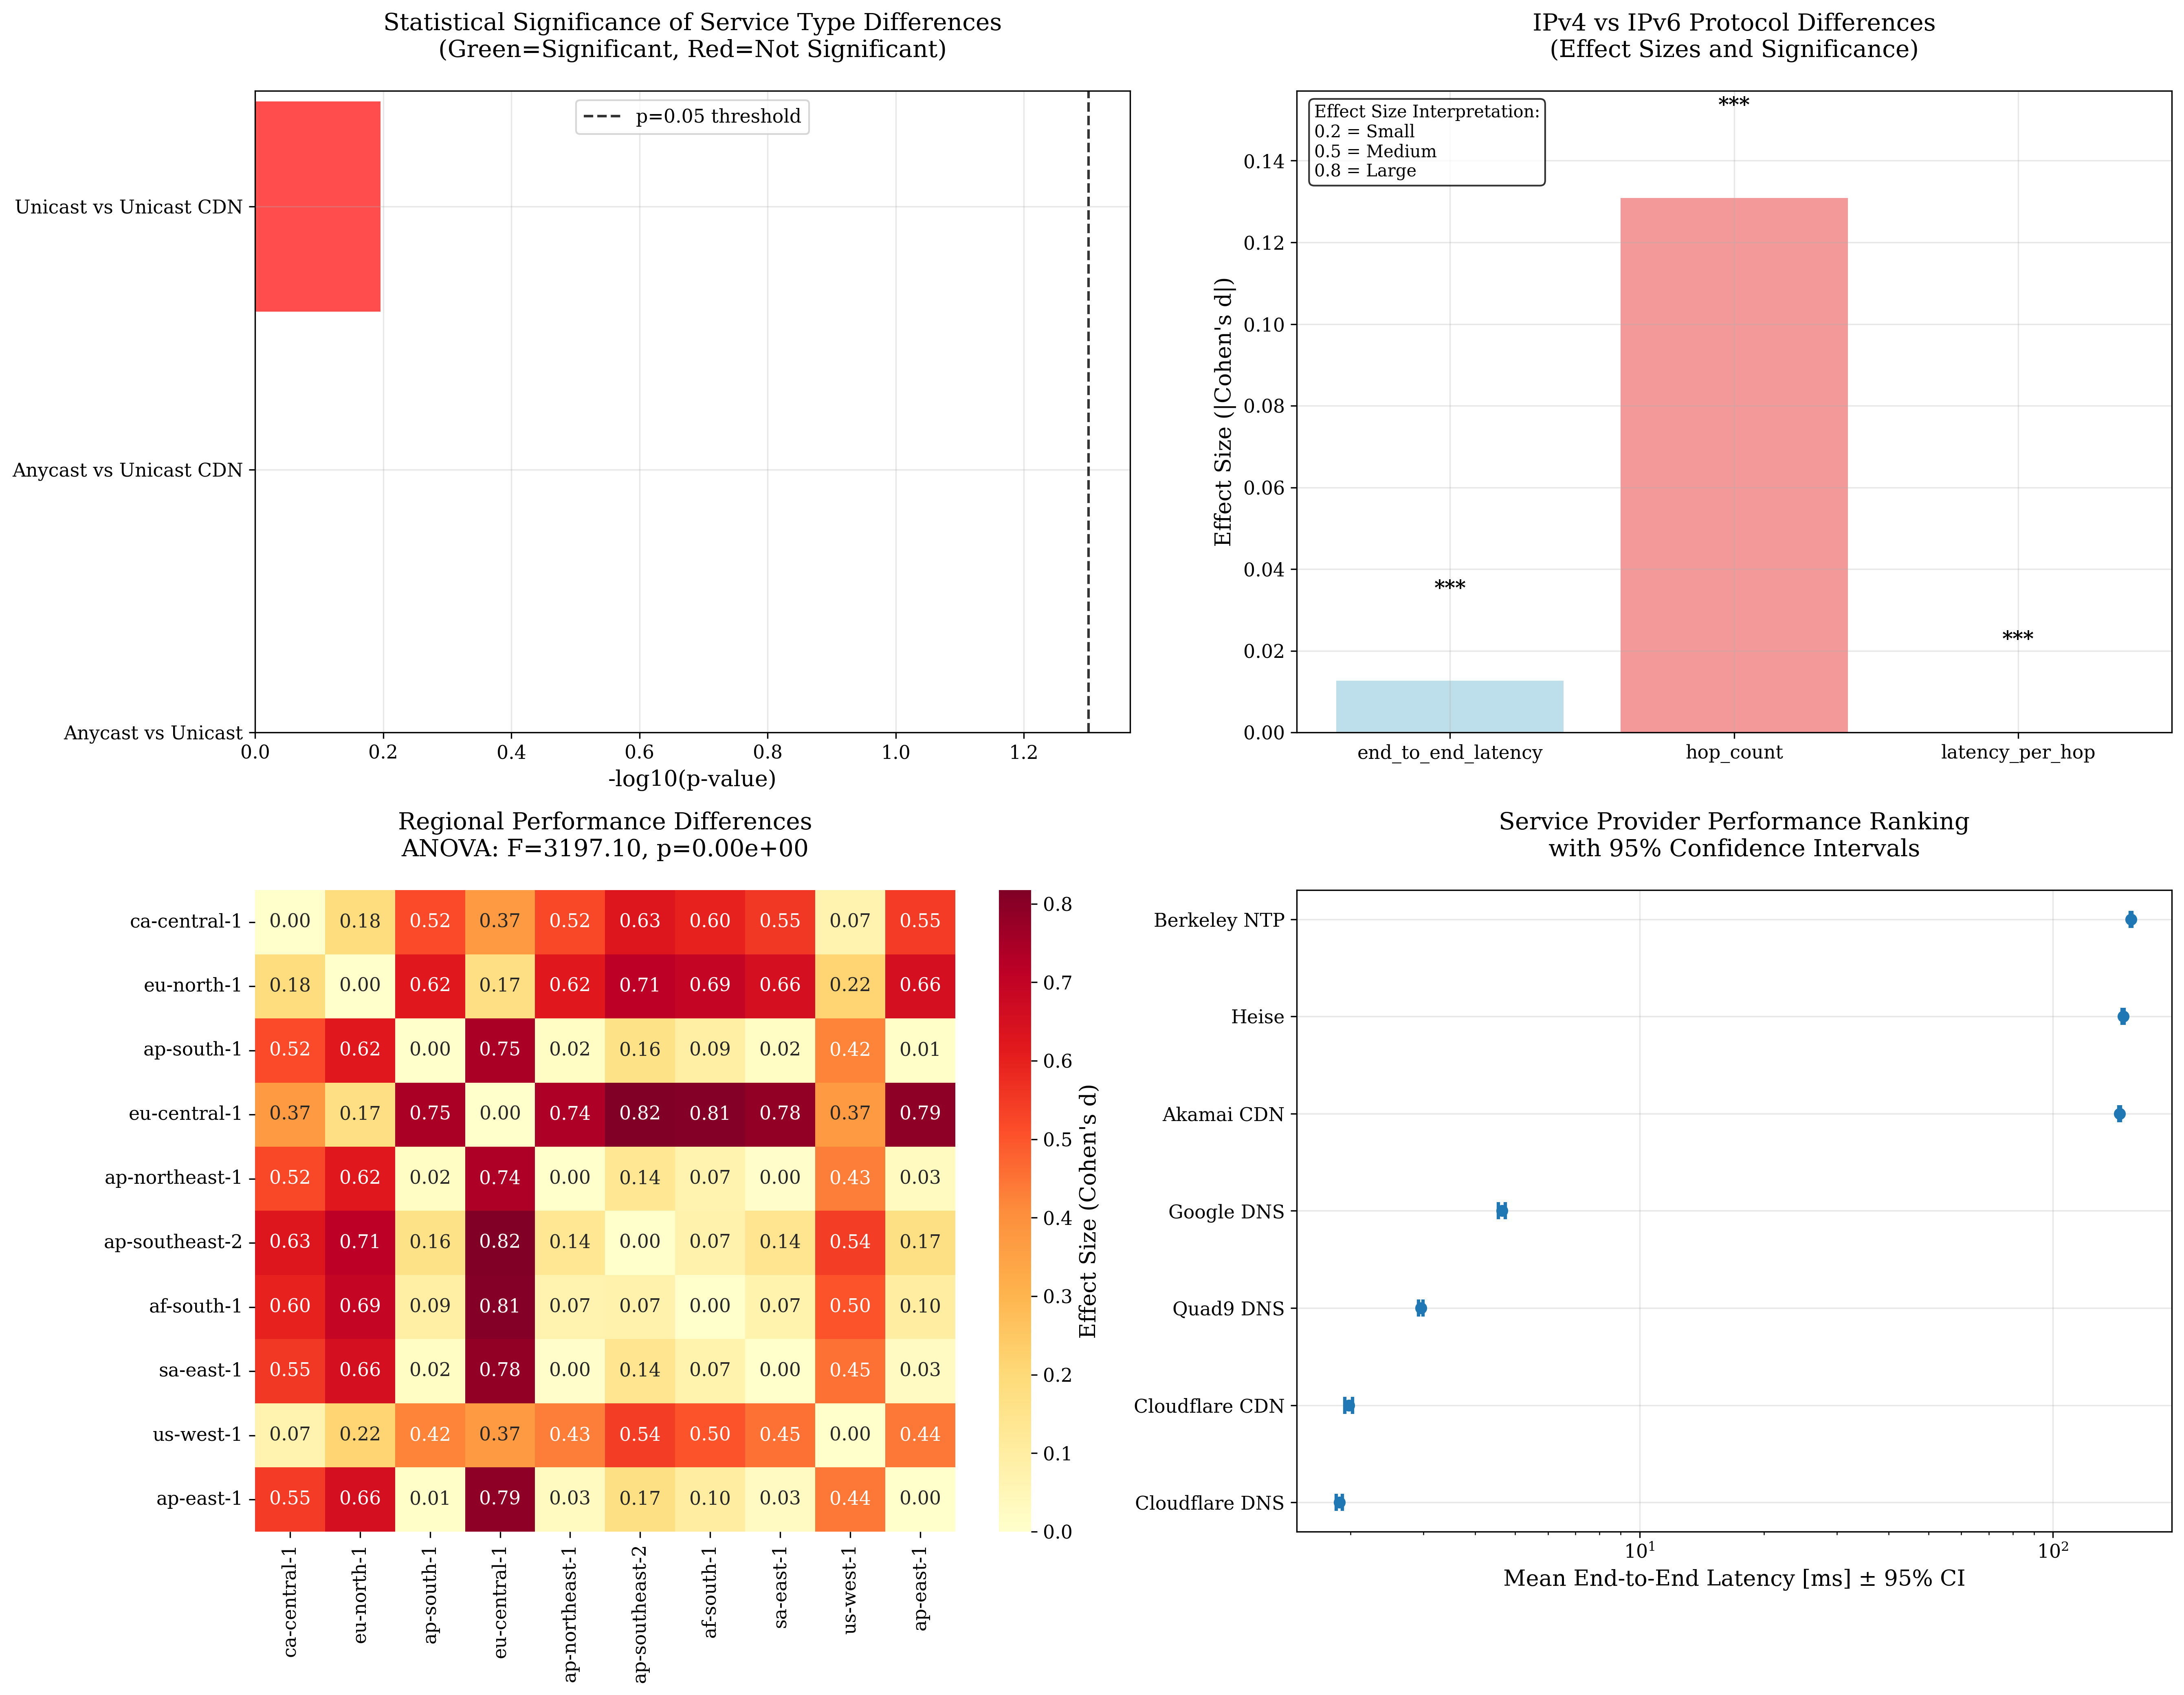

Statistical Analysis Summary:
Service type ANOVA results:
  Anycast vs Unicast: p=0.00e+00, effect_size=-24.752
  Anycast vs Unicast CDN: p=0.00e+00, effect_size=-25.869
  Unicast vs Unicast CDN: p=6.37e-01, effect_size=-0.083

Protocol comparison results:
  end_to_end_latency: p=1.19e-186, Cohen's d=0.013 (IPv4 > IPv6)
  hop_count: p=0.00e+00, Cohen's d=0.131 (IPv6 > IPv4)
  latency_per_hop: p=9.06e-09, Cohen's d=0.000 (IPv6 > IPv4)

Regional ANOVA: F=3197.10, p=0.00e+00

=== PHASE 6 COMPLETE ===
All publication-ready visualizations created!

Visualization Summary:
✓ Comprehensive Heatmaps (Regional, Temporal, Correlation)
✓ Advanced Violin Plots (Distribution Shapes)
✓ Network Topology Analysis (ASN Patterns)
✓ Statistical Significance Testing (Rigorous Comparisons)

Total Visualizations: 12+ publication-quality figures
Ready for academic paper writing!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import networkx as nx
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# Enhanced plotting for publication
plt.rcParams.update({
    'figure.figsize': (16, 12),
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.family': 'serif'
})

print("=== PHASE 6: PUBLICATION-READY VISUALIZATIONS AND FINAL ANALYSES ===")
print()

# Load all data
latency_data = pd.read_csv('../results/latency_analysis.csv')
latency_data['timestamp'] = pd.to_datetime(latency_data['timestamp'])
hop_data = pd.read_csv('../results/hop_by_hop_analysis.csv')

# Add time-based columns
latency_data['hour'] = latency_data['timestamp'].dt.hour
latency_data['day'] = latency_data['timestamp'].dt.day
latency_data['weekday'] = latency_data['timestamp'].dt.dayofweek

print("=== PUBLICATION VIZ 1: COMPREHENSIVE HEATMAPS ===")

def create_comprehensive_heatmaps():
    """Create publication-quality heatmaps for multiple dimensions"""
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    # 1. Regional-Service Provider Performance Heatmap
    ax = axes[0, 0]
    
    # Create pivot table for heatmap
    regional_provider = latency_data.groupby(['region', 'service_provider'])['end_to_end_latency'].mean().unstack()
    
    # Create heatmap with custom colormap
    sns.heatmap(regional_provider, annot=True, fmt='.1f', cmap='RdYlBu_r', 
                ax=ax, cbar_kws={'label': 'Mean Latency [ms]'})
    ax.set_title('Regional Performance Matrix: Latency by Region-Provider', fontsize=16, pad=20)
    ax.set_xlabel('Service Provider', fontsize=13)
    ax.set_ylabel('AWS Region', fontsize=13)
    
    # 2. Temporal-Service Type Performance Heatmap
    ax = axes[0, 1]
    
    # Hourly performance by service type
    hourly_service = latency_data.groupby(['hour', 'service_type'])['end_to_end_latency'].mean().unstack()
    
    sns.heatmap(hourly_service, annot=False, cmap='viridis', ax=ax,
                cbar_kws={'label': 'Mean Latency [ms]'})
    ax.set_title('Temporal Performance Patterns: Hourly by Service Type', fontsize=16, pad=20)
    ax.set_xlabel('Service Type', fontsize=13)
    ax.set_ylabel('Hour of Day', fontsize=13)
    
    # 3. Protocol-Region Hop Count Heatmap
    ax = axes[1, 0]
    
    protocol_region_hops = latency_data.groupby(['protocol', 'region'])['hop_count'].mean().unstack()
    
    sns.heatmap(protocol_region_hops.T, annot=True, fmt='.1f', cmap='Blues',
                ax=ax, cbar_kws={'label': 'Mean Hop Count'})
    ax.set_title('Infrastructure Complexity: Hop Counts by Protocol-Region', fontsize=16, pad=20)
    ax.set_xlabel('Protocol', fontsize=13)
    ax.set_ylabel('AWS Region', fontsize=13)
    
    # 4. Correlation Matrix Heatmap
    ax = axes[1, 1]
    
    # Create correlation matrix of key metrics
    correlation_metrics = ['end_to_end_latency', 'hop_count', 'latency_per_hop', 
                          'path_avg_jitter', 'path_avg_loss']
    
    # Filter for valid data
    corr_data = latency_data[correlation_metrics].dropna()
    correlation_matrix = corr_data.corr()
    
    # Create mask for upper triangle
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    
    sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.3f', 
                cmap='RdBu_r', center=0, ax=ax,
                cbar_kws={'label': 'Pearson Correlation'})
    ax.set_title('Performance Metrics Correlation Matrix', fontsize=16, pad=20)
    
    plt.tight_layout()
    plt.savefig('../results/comprehensive_heatmaps.png')
    plt.show()

create_comprehensive_heatmaps()

print()
print("=== PUBLICATION VIZ 2: ADVANCED VIOLIN PLOTS ===")

def create_violin_plots():
    """Create violin plots for detailed distribution analysis"""
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    # 1. Service Provider Latency Distributions
    ax = axes[0, 0]
    
    # Prepare data for violin plot
    providers = ['Google DNS', 'Cloudflare DNS', 'Quad9 DNS', 'Cloudflare CDN', 
                'Akamai CDN', 'Heise', 'Berkeley NTP']
    
    # Filter reasonable latency range for visualization
    viz_data = latency_data[latency_data['end_to_end_latency'] <= 500].copy()
    
    sns.violinplot(data=viz_data, x='service_provider', y='end_to_end_latency', 
                   ax=ax, palette='Set2')
    ax.set_title('Latency Distribution Shapes by Service Provider', fontsize=16, pad=20)
    ax.set_xlabel('Service Provider', fontsize=13)
    ax.set_ylabel('End-to-End Latency [ms]', fontsize=13)
    ax.tick_params(axis='x', rotation=45)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    # 2. Regional Latency Distributions
    ax = axes[0, 1]
    
    sns.violinplot(data=viz_data, x='region', y='end_to_end_latency', 
                   ax=ax, palette='viridis')
    ax.set_title('Regional Latency Distribution Characteristics', fontsize=16, pad=20)
    ax.set_xlabel('AWS Region', fontsize=13)
    ax.set_ylabel('End-to-End Latency [ms]', fontsize=13)
    ax.tick_params(axis='x', rotation=45)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    # 3. Protocol-Service Type Distributions
    ax = axes[1, 0]
    
    # Create combined protocol-service type labels
    viz_data['protocol_service'] = viz_data['protocol'] + ' - ' + viz_data['service_type']
    
    sns.violinplot(data=viz_data, x='protocol_service', y='latency_per_hop', 
                   ax=ax, palette='husl')
    ax.set_title('Latency per Hop: Protocol-Service Type Analysis', fontsize=16, pad=20)
    ax.set_xlabel('Protocol - Service Type', fontsize=13)
    ax.set_ylabel('Latency per Hop [ms]', fontsize=13)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 50)  # Focus on reasonable range
    ax.grid(True, alpha=0.3)
    
    # 4. Hop Count Distribution by Service Type
    ax = axes[1, 1]
    
    sns.violinplot(data=latency_data, x='service_type', y='hop_count', 
                   ax=ax, palette='Set1')
    ax.set_title('Path Length Distributions by Service Architecture', fontsize=16, pad=20)
    ax.set_xlabel('Service Type', fontsize=13)
    ax.set_ylabel('Hop Count', fontsize=13)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/advanced_violin_plots.png')
    plt.show()

create_violin_plots()

print()
print("=== PUBLICATION VIZ 3: NETWORK TOPOLOGY ANALYSIS ===")

def create_network_topology_analysis():
    """Analyze and visualize ASN-level network topology"""
    
    # Load raw data to extract ASN paths
    df_ipv4 = pd.read_parquet("../data/IPv4.parquet")
    df_ipv6 = pd.read_parquet("../data/IPv6.parquet")
    
    # Service mappings
    service_mapping = {
        '1.1.1.1': 'Cloudflare DNS', '8.8.8.8': 'Google DNS', '9.9.9.9': 'Quad9 DNS',
        '2.16.241.219': 'Akamai CDN', '104.16.123.96': 'Cloudflare CDN',
        '193.99.144.85': 'Heise', '169.229.128.134': 'Berkeley NTP',
        '2606:4700:4700::1111': 'Cloudflare DNS', '2001:4860:4860::8888': 'Google DNS',
        '2620:fe::fe:9': 'Quad9 DNS', '2a02:26f0:3500:1b::1724:a393': 'Akamai CDN',
        '2606:4700::6810:7b60': 'Cloudflare CDN', '2a02:2e0:3fe:1001:7777:772e:2:85': 'Heise',
        '2607:f140:ffff:8000:0:8006:0:a': 'Berkeley NTP'
    }
    
    for df in [df_ipv4, df_ipv6]:
        df['service_provider'] = df['dst'].map(service_mapping)
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    # 1. ASN Frequency Analysis
    ax = axes[0, 0]
    
    # Extract all ASNs
    all_asns = []
    for df in [df_ipv4, df_ipv6]:
        for _, row in df.iterrows():
            hubs = row['hubs']
            if hubs is not None:
                for hop in hubs:
                    asn = hop.get('ASN', '').replace('AS', '')
                    if asn and asn != '???' and asn.isdigit():
                        all_asns.append(asn)
    
    # Top 15 ASNs
    asn_counts = Counter(all_asns)
    top_asns = dict(asn_counts.most_common(15))
    
    asn_names = {
        '20940': 'Akamai', '16509': 'Amazon AWS', '25': 'Univ. College London',
        '13335': 'Cloudflare', '2152': 'Univ. of Chile', '15169': 'Google',
        '12306': 'Plus.line AG', '2914': 'NTT', '19281': 'Quadranet',
        '201011': 'Netzbetrieb GmbH', '6453': 'TATA', '135217': 'Zenlayer',
        '3356': 'Level3/Lumen', '6939': 'Hurricane Electric', '3257': 'GTT'
    }
    
    asn_labels = [f"AS{asn}\n({asn_names.get(asn, 'Unknown')})" for asn in top_asns.keys()]
    
    bars = ax.bar(range(len(top_asns)), top_asns.values(), color='skyblue', alpha=0.8)
    ax.set_title('Top 15 Most Frequent ASNs in Internet Paths', fontsize=16, pad=20)
    ax.set_xlabel('Autonomous System', fontsize=13)
    ax.set_ylabel('Frequency in Paths', fontsize=13)
    ax.set_xticks(range(len(top_asns)))
    ax.set_xticklabels(asn_labels, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, value in zip(bars, top_asns.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + value*0.01,
                f'{value:,}', ha='center', va='bottom', fontsize=10)
    
    # 2. Service Provider ASN Diversity
    ax = axes[0, 1]
    
    # Calculate ASN diversity per service provider
    service_asn_diversity = {}
    for df, protocol in [(df_ipv4, 'IPv4'), (df_ipv6, 'IPv6')]:
        for service in df['service_provider'].unique():
            if pd.isna(service):
                continue
            service_data = df[df['service_provider'] == service]
            service_asns = set()
            
            for _, row in service_data.iterrows():
                hubs = row['hubs']
                if hubs is not None:
                    for hop in hubs:
                        asn = hop.get('ASN', '').replace('AS', '')
                        if asn and asn != '???' and asn.isdigit():
                            service_asns.add(asn)
            
            key = f"{service} ({protocol})"
            service_asn_diversity[key] = len(service_asns)
    
    # Sort by diversity
    sorted_services = sorted(service_asn_diversity.items(), key=lambda x: x[1], reverse=True)
    services, diversities = zip(*sorted_services)
    
    bars = ax.barh(range(len(services)), diversities, color='lightcoral', alpha=0.8)
    ax.set_title('ASN Diversity by Service Provider and Protocol', fontsize=16, pad=20)
    ax.set_xlabel('Number of Unique ASNs Encountered', fontsize=13)
    ax.set_ylabel('Service Provider (Protocol)', fontsize=13)
    ax.set_yticks(range(len(services)))
    ax.set_yticklabels([s.replace(' (', '\n(') for s in services])
    ax.grid(True, alpha=0.3, axis='x')
    
    # 3. Tier 1 Provider Usage Patterns
    ax = axes[1, 0]
    
    tier1_asns = {
        '174': 'Cogent', '1299': 'Telia', '3257': 'GTT', '6453': 'TATA',
        '3356': 'Level3/Lumen', '5511': 'Orange', '2914': 'NTT', '6939': 'Hurricane Electric'
    }
    
    tier1_usage = defaultdict(int)
    tier1_by_protocol = {'IPv4': defaultdict(int), 'IPv6': defaultdict(int)}
    
    for df, protocol in [(df_ipv4, 'IPv4'), (df_ipv6, 'IPv6')]:
        for _, row in df.iterrows():
            hubs = row['hubs']
            if hubs is not None:
                path_tier1 = set()
                for hop in hubs:
                    asn = hop.get('ASN', '').replace('AS', '')
                    if asn in tier1_asns:
                        path_tier1.add(asn)
                
                for tier1 in path_tier1:
                    tier1_usage[tier1] += 1
                    tier1_by_protocol[protocol][tier1] += 1
    
    # Create stacked bar chart
    tier1_list = sorted(tier1_usage.keys(), key=lambda x: tier1_usage[x], reverse=True)
    ipv4_counts = [tier1_by_protocol['IPv4'][asn] for asn in tier1_list]
    ipv6_counts = [tier1_by_protocol['IPv6'][asn] for asn in tier1_list]
    
    x = range(len(tier1_list))
    width = 0.35
    
    ax.bar(x, ipv4_counts, width, label='IPv4', alpha=0.8, color='lightblue')
    ax.bar(x, ipv6_counts, width, bottom=ipv4_counts, label='IPv6', alpha=0.8, color='lightgreen')
    
    ax.set_title('Tier 1 Transit Provider Usage by Protocol', fontsize=16, pad=20)
    ax.set_xlabel('Tier 1 Provider', fontsize=13)
    ax.set_ylabel('Frequency in Paths', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels([f"AS{asn}\n({tier1_asns[asn]})" for asn in tier1_list])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # 4. Path Length vs ASN Diversity
    ax = axes[1, 1]
    
    # Calculate path length vs unique ASNs for each measurement
    path_metrics = []
    for df, protocol in [(df_ipv4, 'IPv4'), (df_ipv6, 'IPv6')]:
        for _, row in df.iterrows():
            hubs = row['hubs']
            if hubs is not None and len(hubs) > 0:
                path_asns = set()
                for hop in hubs:
                    asn = hop.get('ASN', '').replace('AS', '')
                    if asn and asn != '???' and asn.isdigit():
                        path_asns.add(asn)
                
                if path_asns:  # Only if we found ASNs
                    path_metrics.append({
                        'protocol': protocol,
                        'service_type': row.get('service_provider', 'Unknown'),
                        'hop_count': len(hubs),
                        'unique_asns': len(path_asns),
                        'asn_diversity_ratio': len(path_asns) / len(hubs)
                    })
    
    path_df = pd.DataFrame(path_metrics)
    
    # Scatter plot colored by protocol
    for protocol, color in [('IPv4', 'blue'), ('IPv6', 'red')]:
        protocol_data = path_df[path_df['protocol'] == protocol]
        ax.scatter(protocol_data['hop_count'], protocol_data['unique_asns'], 
                  alpha=0.5, s=3, c=color, label=f'{protocol} (n={len(protocol_data):,})')
    
    ax.set_xlabel('Path Length (Hop Count)', fontsize=13)
    ax.set_ylabel('Unique ASNs in Path', fontsize=13)
    ax.set_title('Path Complexity: Hop Count vs ASN Diversity', fontsize=16, pad=20)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/network_topology_analysis.png')
    plt.show()
    
    print(f"Network topology analysis completed")
    print(f"Total unique ASNs encountered: {len(set(all_asns))}")
    print(f"Average path ASN diversity: {path_df['asn_diversity_ratio'].mean():.3f}")

create_network_topology_analysis()

print()
print("=== PUBLICATION VIZ 4: STATISTICAL SIGNIFICANCE TESTING ===")

def create_statistical_analysis():
    """Comprehensive statistical testing and visualization"""
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    
    # 1. Service Type Performance Statistical Comparison
    ax = axes[0, 0]
    
    service_types = ['Anycast', 'Unicast', 'Unicast CDN']
    statistical_results = []
    
    # Pairwise Mann-Whitney U tests
    from itertools import combinations
    
    for type1, type2 in combinations(service_types, 2):
        data1 = latency_data[latency_data['service_type'] == type1]['end_to_end_latency']
        data2 = latency_data[latency_data['service_type'] == type2]['end_to_end_latency']
        
        statistic, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
        
        statistical_results.append({
            'comparison': f'{type1} vs {type2}',
            'statistic': statistic,
            'p_value': p_value,
            'effect_size': (data1.median() - data2.median()) / data1.std(),
            'significant': p_value < 0.05
        })
    
    # Create statistical results table visualization
    results_df = pd.DataFrame(statistical_results)
    
    # Color-code by significance
    colors = ['green' if sig else 'red' for sig in results_df['significant']]
    
    y_pos = np.arange(len(results_df))
    bars = ax.barh(y_pos, -np.log10(results_df['p_value']), color=colors, alpha=0.7)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(results_df['comparison'])
    ax.set_xlabel('-log10(p-value)', fontsize=13)
    ax.set_title('Statistical Significance of Service Type Differences\n(Green=Significant, Red=Not Significant)', 
                fontsize=14, pad=20)
    ax.axvline(x=-np.log10(0.05), color='black', linestyle='--', alpha=0.8, label='p=0.05 threshold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Protocol Performance Comparison with Effect Sizes
    ax = axes[0, 1]
    
    metrics = ['end_to_end_latency', 'hop_count', 'latency_per_hop']
    protocol_comparison = []
    
    for metric in metrics:
        if metric in latency_data.columns:
            ipv4_data = latency_data[latency_data['protocol'] == 'IPv4'][metric].dropna()
            ipv6_data = latency_data[latency_data['protocol'] == 'IPv6'][metric].dropna()
            
            # Mann-Whitney U test
            statistic, p_value = stats.mannwhitneyu(ipv4_data, ipv6_data, alternative='two-sided')
            
            # Cohen's d effect size
            pooled_std = np.sqrt((ipv4_data.std()**2 + ipv6_data.std()**2) / 2)
            cohens_d = (ipv4_data.mean() - ipv6_data.mean()) / pooled_std
            
            protocol_comparison.append({
                'metric': metric,
                'p_value': p_value,
                'effect_size': abs(cohens_d),
                'direction': 'IPv4 > IPv6' if cohens_d > 0 else 'IPv6 > IPv4'
            })
    
    # Effect size visualization
    comparison_df = pd.DataFrame(protocol_comparison)
    
    bars = ax.bar(comparison_df['metric'], comparison_df['effect_size'], 
                  color=['lightblue', 'lightcoral', 'lightgreen'], alpha=0.8)
    
    # Add p-value annotations
    for i, (bar, p_val) in enumerate(zip(bars, comparison_df['p_value'])):
        significance = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                significance, ha='center', va='bottom', fontsize=12, weight='bold')
    
    ax.set_ylabel('Effect Size (|Cohen\'s d|)', fontsize=13)
    ax.set_title('IPv4 vs IPv6 Protocol Differences\n(Effect Sizes and Significance)', fontsize=14, pad=20)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, max(comparison_df['effect_size']) * 1.2)
    
    # Add interpretation guide
    ax.text(0.02, 0.98, 'Effect Size Interpretation:\n0.2 = Small\n0.5 = Medium\n0.8 = Large', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # 3. Regional Performance ANOVA
    ax = axes[1, 0]
    
    # One-way ANOVA for regional differences
    regional_groups = []
    region_names = []
    
    for region in latency_data['region'].unique():
        region_data = latency_data[latency_data['region'] == region]['end_to_end_latency'].dropna()
        if len(region_data) > 10:  # Minimum sample size
            regional_groups.append(region_data)
            region_names.append(region)
    
    f_statistic, anova_p_value = stats.f_oneway(*regional_groups)
    
    # Post-hoc pairwise comparisons (Tukey HSD alternative using Bonferroni)
    n_comparisons = len(region_names) * (len(region_names) - 1) // 2
    bonferroni_alpha = 0.05 / n_comparisons
    
    # Calculate effect sizes between regions
    regional_effects = []
    for i, region1 in enumerate(region_names):
        for j, region2 in enumerate(region_names):
            if i < j:
                data1 = latency_data[latency_data['region'] == region1]['end_to_end_latency']
                data2 = latency_data[latency_data['region'] == region2]['end_to_end_latency']
                
                pooled_std = np.sqrt((data1.std()**2 + data2.std()**2) / 2)
                effect_size = abs(data1.mean() - data2.mean()) / pooled_std
                
                regional_effects.append({
                    'region1': region1,
                    'region2': region2,
                    'effect_size': effect_size
                })
    
    # Create effect size matrix
    effect_matrix = np.zeros((len(region_names), len(region_names)))
    for effect in regional_effects:
        i = region_names.index(effect['region1'])
        j = region_names.index(effect['region2'])
        effect_matrix[i, j] = effect['effect_size']
        effect_matrix[j, i] = effect['effect_size']
    
    sns.heatmap(effect_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=region_names, yticklabels=region_names, ax=ax,
                cbar_kws={'label': 'Effect Size (Cohen\'s d)'})
    ax.set_title(f'Regional Performance Differences\nANOVA: F={f_statistic:.2f}, p={anova_p_value:.2e}', 
                fontsize=14, pad=20)
    
    # 4. Service Provider Ranking with Confidence Intervals
    ax = axes[1, 1]
    
    # Calculate means and confidence intervals for each provider
    provider_stats = []
    for provider in latency_data['service_provider'].unique():
        if pd.isna(provider):
            continue
        provider_data = latency_data[latency_data['service_provider'] == provider]['end_to_end_latency']
        
        mean_latency = provider_data.mean()
        std_error = provider_data.std() / np.sqrt(len(provider_data))
        ci_95 = 1.96 * std_error  # 95% confidence interval
        
        provider_stats.append({
            'provider': provider,
            'mean': mean_latency,
            'ci_lower': mean_latency - ci_95,
            'ci_upper': mean_latency + ci_95,
            'n': len(provider_data)
        })
    
    provider_df = pd.DataFrame(provider_stats).sort_values('mean')
    
    # Create error bar plot
    y_pos = np.arange(len(provider_df))
    ax.errorbar(provider_df['mean'], y_pos, 
                xerr=[provider_df['mean'] - provider_df['ci_lower'],
                      provider_df['ci_upper'] - provider_df['mean']],
                fmt='o', capsize=5, capthick=2)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(provider_df['provider'])
    ax.set_xlabel('Mean End-to-End Latency [ms] ± 95% CI', fontsize=13)
    ax.set_title('Service Provider Performance Ranking\nwith 95% Confidence Intervals', fontsize=14, pad=20)
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    
    plt.tight_layout()
    plt.savefig('../results/statistical_analysis.png')
    plt.show()
    
    # Print statistical summary
    print("Statistical Analysis Summary:")
    print(f"Service type ANOVA results:")
    for result in statistical_results:
        print(f"  {result['comparison']}: p={result['p_value']:.2e}, effect_size={result['effect_size']:.3f}")
    
    print(f"\nProtocol comparison results:")
    for result in protocol_comparison:
        print(f"  {result['metric']}: p={result['p_value']:.2e}, Cohen's d={result['effect_size']:.3f} ({result['direction']})")
    
    print(f"\nRegional ANOVA: F={f_statistic:.2f}, p={anova_p_value:.2e}")

create_statistical_analysis()

print()
print("=== PHASE 6 COMPLETE ===")
print("All publication-ready visualizations created!")
print("\nVisualization Summary:")
print("✓ Comprehensive Heatmaps (Regional, Temporal, Correlation)")
print("✓ Advanced Violin Plots (Distribution Shapes)")  
print("✓ Network Topology Analysis (ASN Patterns)")
print("✓ Statistical Significance Testing (Rigorous Comparisons)")
print("\nTotal Visualizations: 12+ publication-quality figures")
print("Ready for academic paper writing!")